In [1]:
%matplotlib inline

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import sys

sys.path.append('../../..')

from utilss.std.data_io import read_focal_data, read_focal_centroids_and_energy_characteristics, save_focal_centroids_and_energy_characteristics
from utilss.image_analyzis.approx_radius import IDX_LIST
from utilss.image_analyzis.energy_characteristics import get_image_from_characteristics, get_energy_characteristics
from utilss.physical_loss import compute_expected_hit_coors, center_of_mass

In [48]:
DATA_DIR = Path('../../../data')

# CLEANED_DATA_DIR = DATA_DIR / 'single-shower-09062025' / 'cleaned-2-energy-ratio_30000'
# CLEANED_DATA_DIR = DATA_DIR / 'single-shower-first' / 'cleaned-1'
CLEANED_DATA_DIR = DATA_DIR / 'many-showers' / 'cleaned-1'
CHARACTERISITCS_DIR = CLEANED_DATA_DIR
os.makedirs(CHARACTERISITCS_DIR, exist_ok=True)

data = read_focal_data(CLEANED_DATA_DIR)
particles = data['particles']
responses = data['responses']

In [49]:
from utilss.plot import plot_responses_rows

In [50]:
logt = lambda p: np.log(p + 1)
rlogt = lambda p: np.exp(p) - 1

error per repsonse 0.0023195327
error per pixel 2.1038844e-07


(<Figure size 2200x1200 with 30 Axes>,
 array([[<Axes: ylabel='Group 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Group 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Group 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >]],
       dtype=object))

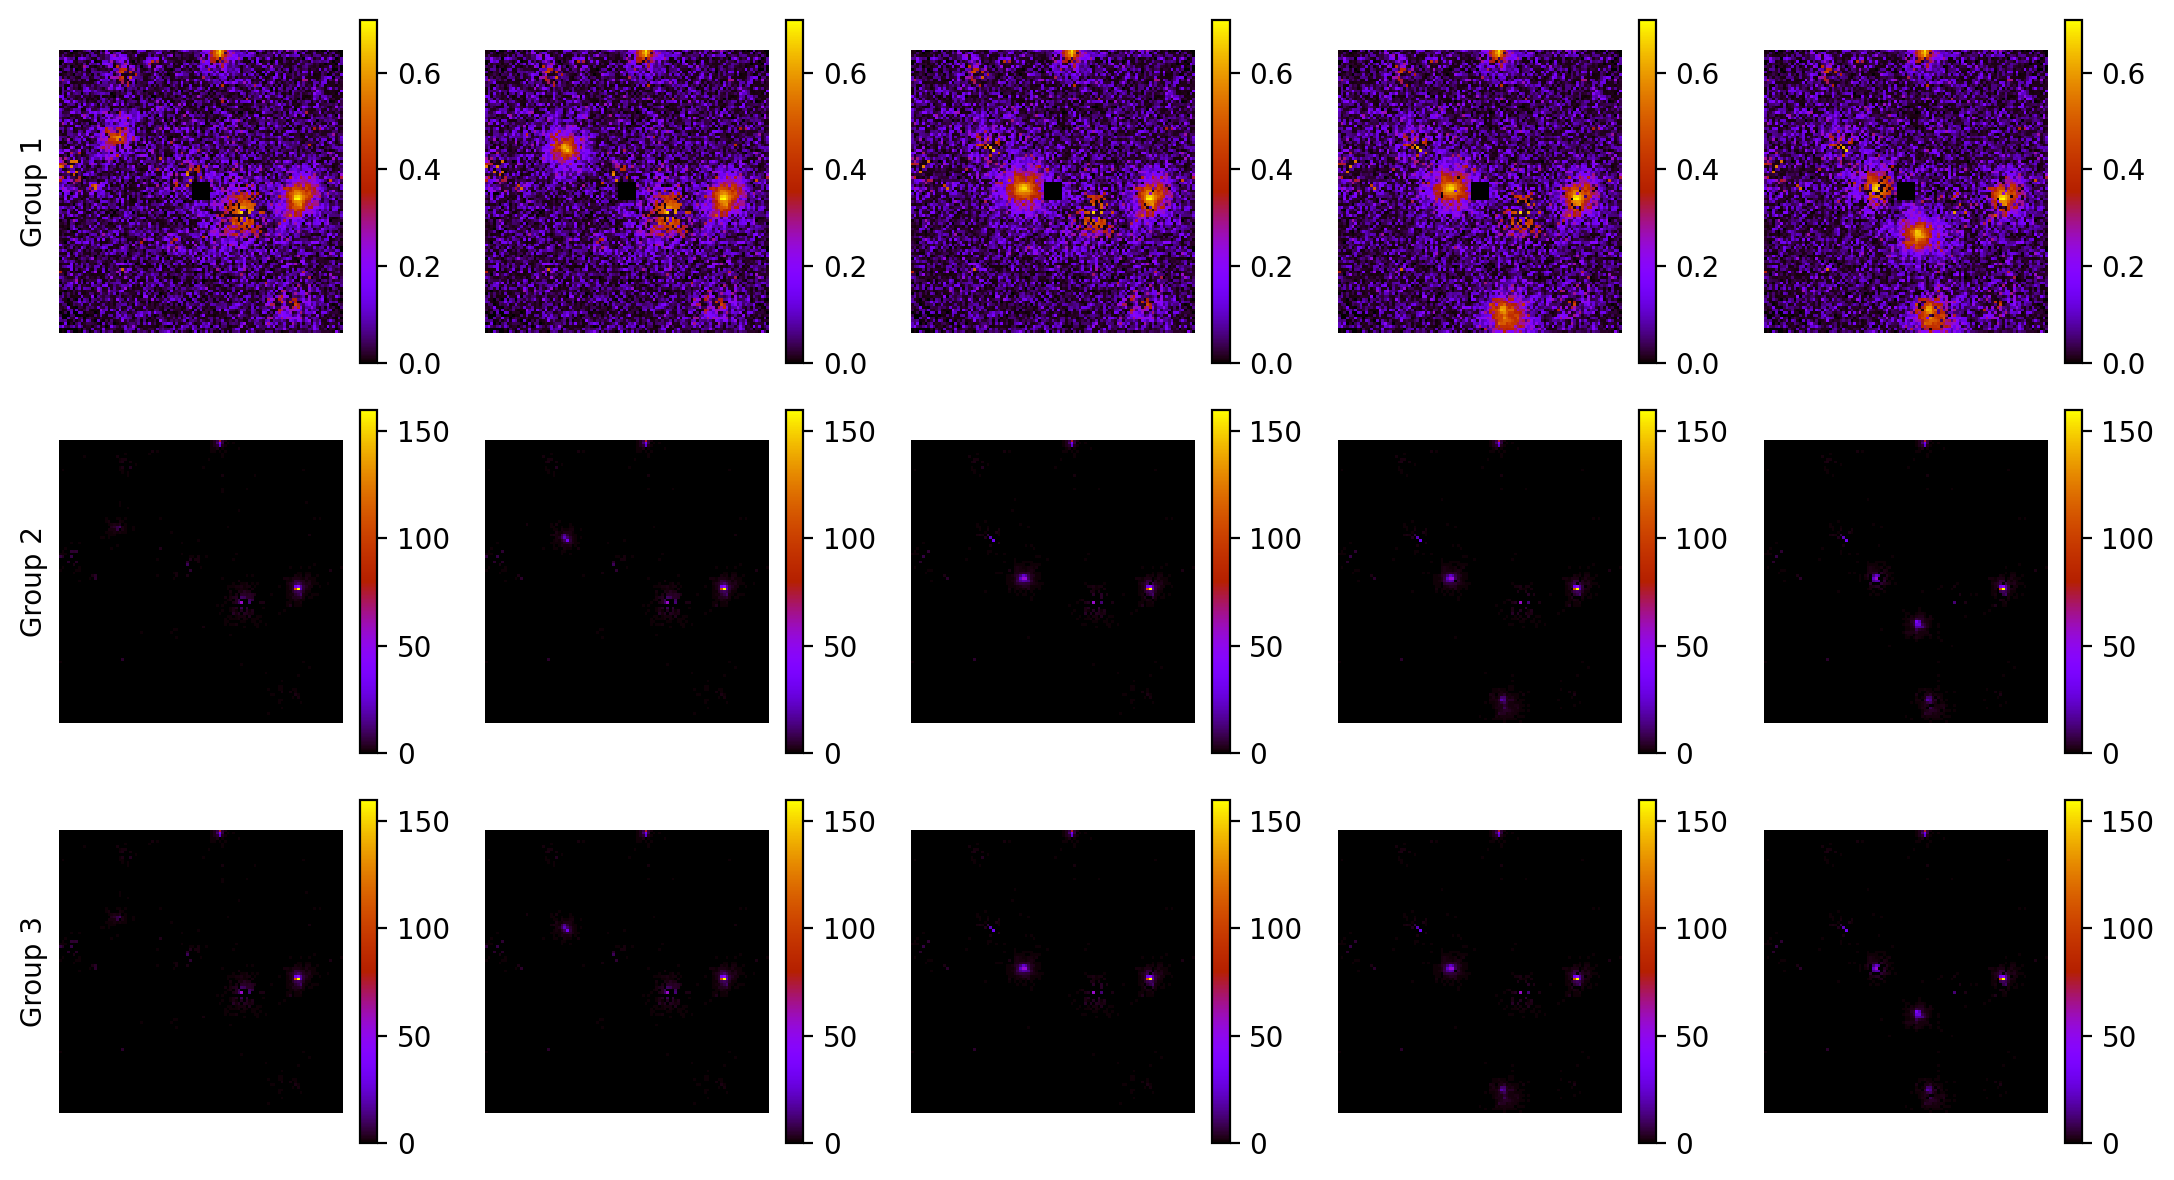

In [51]:
imgs =  logt(logt(logt(logt(responses))))
rimgs = rlogt(rlogt(rlogt(rlogt(imgs))))
print("error per repsonse", np.abs((responses - rimgs)).sum() / responses.shape[0])
print("error per pixel", np.abs((responses - rimgs)).sum() / responses.size)
plot_responses_rows(images=[imgs[:5], rimgs[:5], responses[:5]])

np.float32(64.84583)

In [5]:
with torch.no_grad():
    centroids = center_of_mass(torch.Tensor(responses)).numpy()

In [6]:
from multiprocessing import Pool, cpu_count

def wrapper(args):
    r, c = args
    return get_energy_characteristics(r, c)

args = list(zip(responses, centroids))

with Pool(cpu_count()) as pool:
    results = list(tqdm(pool.imap(wrapper, args), total=len(args)))

energy_characterisitcs = np.vstack(results)


100%|██████████| 53945/53945 [00:15<00:00, 3380.10it/s]


In [7]:
save_focal_centroids_and_energy_characteristics(CHARACTERISITCS_DIR, centroids, energy_characterisitcs)

saved


In [ ]:
centroids, energy_characterisitcs = read_focal_centroids_and_energy_characteristics(CHARACTERISITCS_DIR)

2804.2922468485776


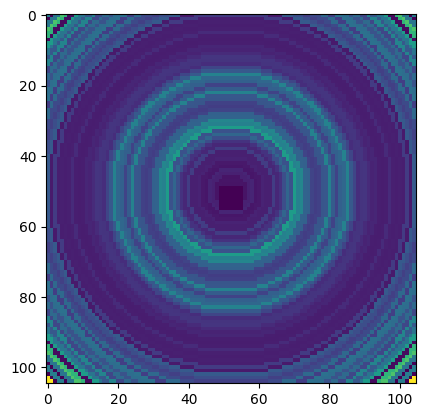

In [4]:
i = 1515
approx_img = get_image_from_characteristics(centroids[i], energy_characterisitcs[i])
print(approx_img.sum())
plt.imshow(np.log(approx_img + 1))